# 顧客離脱予測 - 探索的データ分析 (EDA)

Kaggleの顧客離脱予測データセットを用いて、データの品質確認・中身の把握を行います。

## 1. 必要なライブラリの読み込み

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# 表示設定
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
sns.set_theme(style="whitegrid")

print("ライブラリの読み込み完了")

ライブラリの読み込み完了


## 2. データファイルの読み込み

In [24]:
import os

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data") if "notebooks" in os.getcwd() else os.path.join(os.getcwd(), "data")

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sub   = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"train shape : {train.shape}")
print(f"test  shape : {test.shape}")
print(f"submission  : {sub.shape}")

train shape : (594194, 21)
test  shape : (254655, 20)
submission  : (254655, 2)


## 3. データの先頭行・末尾行の確認

In [25]:
print("=== train 先頭5行 ===")
display(train.head())

print("\n=== train 末尾5行 ===")
display(train.tail())

=== train 先頭5行 ===


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes



=== train 末尾5行 ===


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


## 4. 行数・列数と列名の確認

In [26]:
print(f"行数: {train.shape[0]:,}  列数: {train.shape[1]}")
print(f"\n列名一覧 ({len(train.columns)} 列):")
for i, col in enumerate(train.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n※ testには 'Churn' 列なし（予測対象）")
print(f"test 列数: {test.shape[1]}  ({list(test.columns[-3:])} ... 末尾3列)")

行数: 594,194  列数: 21

列名一覧 (21 列):
   1. id
   2. gender
   3. SeniorCitizen
   4. Partner
   5. Dependents
   6. tenure
   7. PhoneService
   8. MultipleLines
   9. InternetService
  10. OnlineSecurity
  11. OnlineBackup
  12. DeviceProtection
  13. TechSupport
  14. StreamingTV
  15. StreamingMovies
  16. Contract
  17. PaperlessBilling
  18. PaymentMethod
  19. MonthlyCharges
  20. TotalCharges
  21. Churn

※ testには 'Churn' 列なし（予測対象）
test 列数: 20  (['PaymentMethod', 'MonthlyCharges', 'TotalCharges'] ... 末尾3列)


## 5. データ型と基本情報の確認

In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [28]:
# データ型をまとめて表示
dtype_df = pd.DataFrame({
    "dtype": train.dtypes,
    "non_null": train.notnull().sum(),
    "null": train.isnull().sum(),
}).reset_index().rename(columns={"index": "column"})
display(dtype_df)

,column,dtype,non_null,null
0,id,int64,594194,0
1,gender,object,594194,0
2,SeniorCitizen,int64,594194,0
3,Partner,object,594194,0
4,Dependents,object,594194,0
5,tenure,int64,594194,0
6,PhoneService,object,594194,0
7,MultipleLines,object,594194,0
8,InternetService,object,594194,0
9,OnlineSecurity,object,594194,0


## 6. 欠損値の件数と欠損率の確認

In [29]:
def missing_summary(df, name="DataFrame"):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({"欠損件数": missing, "欠損率(%)": missing_pct})
    result = result[result["欠損件数"] > 0].sort_values("欠損率(%)", ascending=False)
    if result.empty:
        print(f"[{name}] 欠損値なし")
    else:
        print(f"[{name}] 欠損あり列:")
        display(result)
    return result

train_missing = missing_summary(train, "train")
test_missing  = missing_summary(test,  "test")

[train] 欠損値なし
[test] 欠損値なし


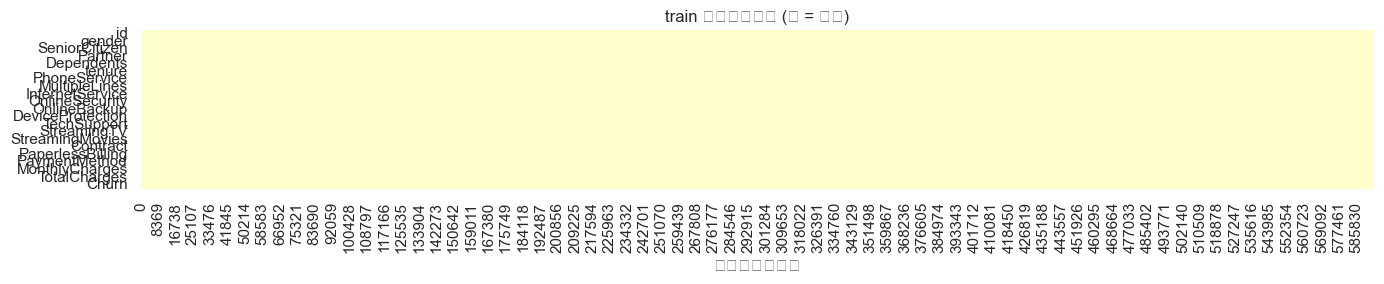

In [30]:
# 欠損値のヒートマップ（trainのみ）
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(train.isnull().T, cbar=False, ax=ax, yticklabels=True, cmap="YlOrRd")
ax.set_title("train 欠損値マップ (黄 = 欠損)")
ax.set_xlabel("行インデックス")
plt.tight_layout()
plt.show()

## 7. 重複データの確認

In [31]:
dup_all  = train.duplicated().sum()
dup_id   = train.duplicated(subset=["id"]).sum()

print(f"全列での重複行数   : {dup_all}")
print(f"id列での重複行数   : {dup_id}")

if dup_id > 0:
    print("\n重複ID の例:")
    display(train[train.duplicated(subset=["id"], keep=False)].head(10))
else:
    print("→ id は全行ユニーク（問題なし）")

全列での重複行数   : 0
id列での重複行数   : 0
→ id は全行ユニーク（問題なし）


## 8. 目的変数（Churn）の中身確認

=== Churn 分布 ===


,件数,割合(%)
Churn,,
No,460377,77.48
Yes,133817,22.52


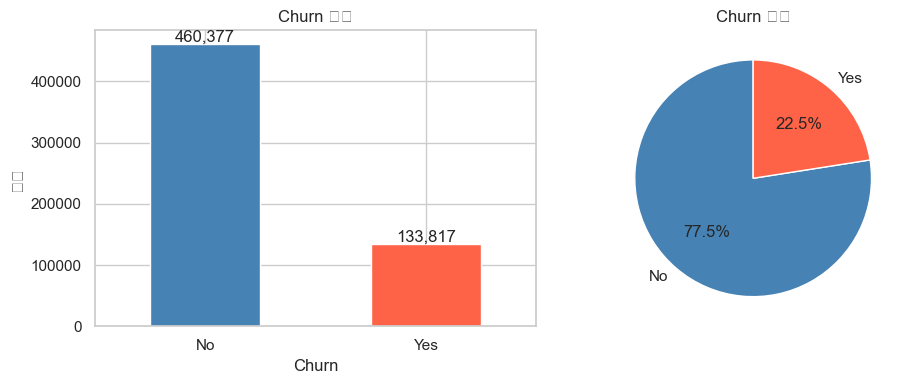

In [32]:
churn_counts = train["Churn"].value_counts()
churn_pct    = train["Churn"].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({"件数": churn_counts, "割合(%)": churn_pct.round(2)})
print("=== Churn 分布 ===")
display(churn_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 棒グラフ
churn_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], rot=0)
axes[0].set_title("Churn 件数")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("件数")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom")

# 円グラフ
axes[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Churn 割合")

plt.tight_layout()
plt.show()

## 9. 数値列の要約統計量の確認

In [33]:
# TotalCharges は object の可能性があるため数値変換を試みる
train["TotalCharges"] = pd.to_numeric(train["TotalCharges"], errors="coerce")

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "id"]
print(f"数値列: {num_cols}\n")
display(train[num_cols].describe().T)

数値列: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']



,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,594194.00,0.11,0.32,0.00,0.00,0.00,0.00,1.00
tenure,594194.00,36.58,25.06,1.00,12.00,35.00,62.00,72.00
MonthlyCharges,594194.00,65.87,31.07,18.25,29.90,74.10,90.80,118.75
TotalCharges,594194.00,2494.38,2353.92,18.80,639.65,1433.65,4263.80,8684.80


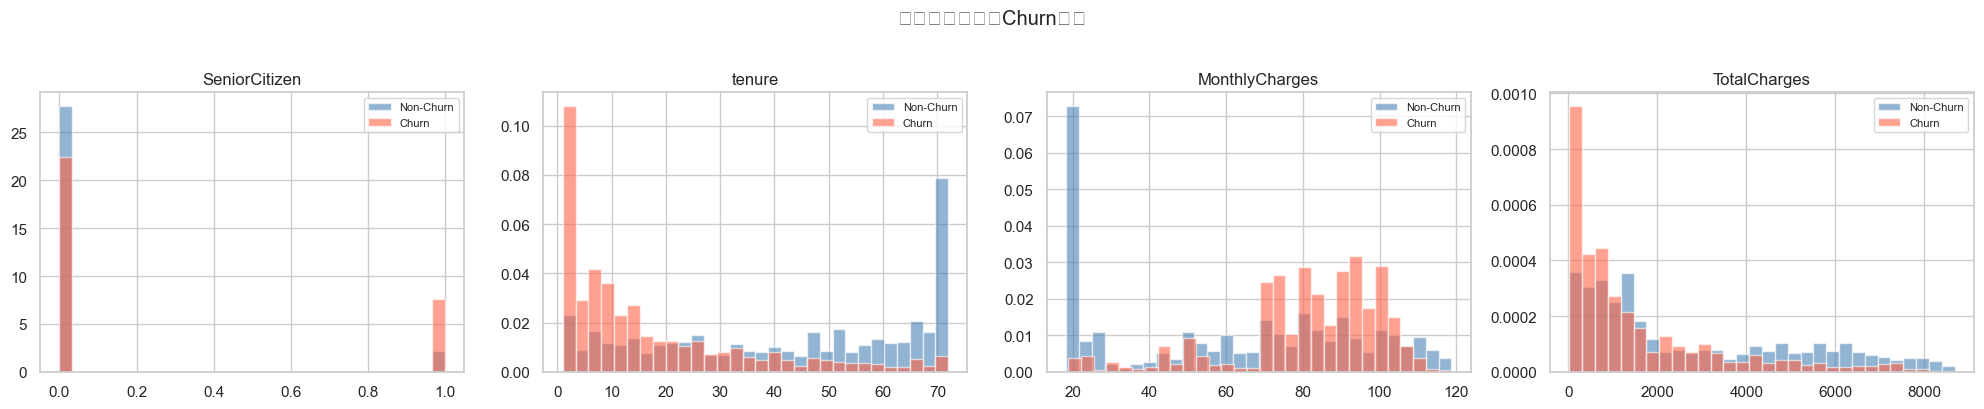

In [34]:
# 数値列のヒストグラム（Churn別に重ね描き）
tmp = train.copy()
tmp["Churn_label"] = tmp["Churn"].map({"No": "Non-Churn", "Yes": "Churn"})

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    for label, color in zip(["Non-Churn", "Churn"], ["steelblue", "tomato"]):
        subset = tmp[tmp["Churn_label"] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("数値列の分布（Churn別）", y=1.02)
plt.tight_layout()
plt.show()

## 10. カテゴリ列のユニーク値と頻度確認

In [35]:
cat_cols = train.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c not in ["id", "Churn"]]
print(f"カテゴリ列 ({len(cat_cols)}列): {cat_cols}\n")

for col in cat_cols:
    vc = train[col].value_counts()
    print(f"--- {col}  (ユニーク数: {train[col].nunique()}) ---")
    display(vc.to_frame("件数").assign(**{"割合(%)": (vc / len(train) * 100).round(2)}))

カテゴリ列 (15列): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

--- gender  (ユニーク数: 2) ---


,件数,割合(%)
gender,,
Female,298738,50.28
Male,295456,49.72


--- Partner  (ユニーク数: 2) ---


,件数,割合(%)
Partner,,
Yes,309554,52.10
No,284640,47.90


--- Dependents  (ユニーク数: 2) ---


...

,件数,割合(%)
Contract,,
Month-to-month,298918,50.31
Two year,186943,31.46
One year,108333,18.23


--- PaperlessBilling  (ユニーク数: 2) ---


,件数,割合(%)
PaperlessBilling,,
Yes,365579,61.53
No,228615,38.47


--- PaymentMethod  (ユニーク数: 4) ---


,件数,割合(%)
PaymentMethod,,
Electronic check,215372,36.25
Credit card (automatic),133705,22.50
Mailed check,123757,20.83
Bank transfer (automatic),121360,20.42


## 11. 簡単な可視化による分布確認

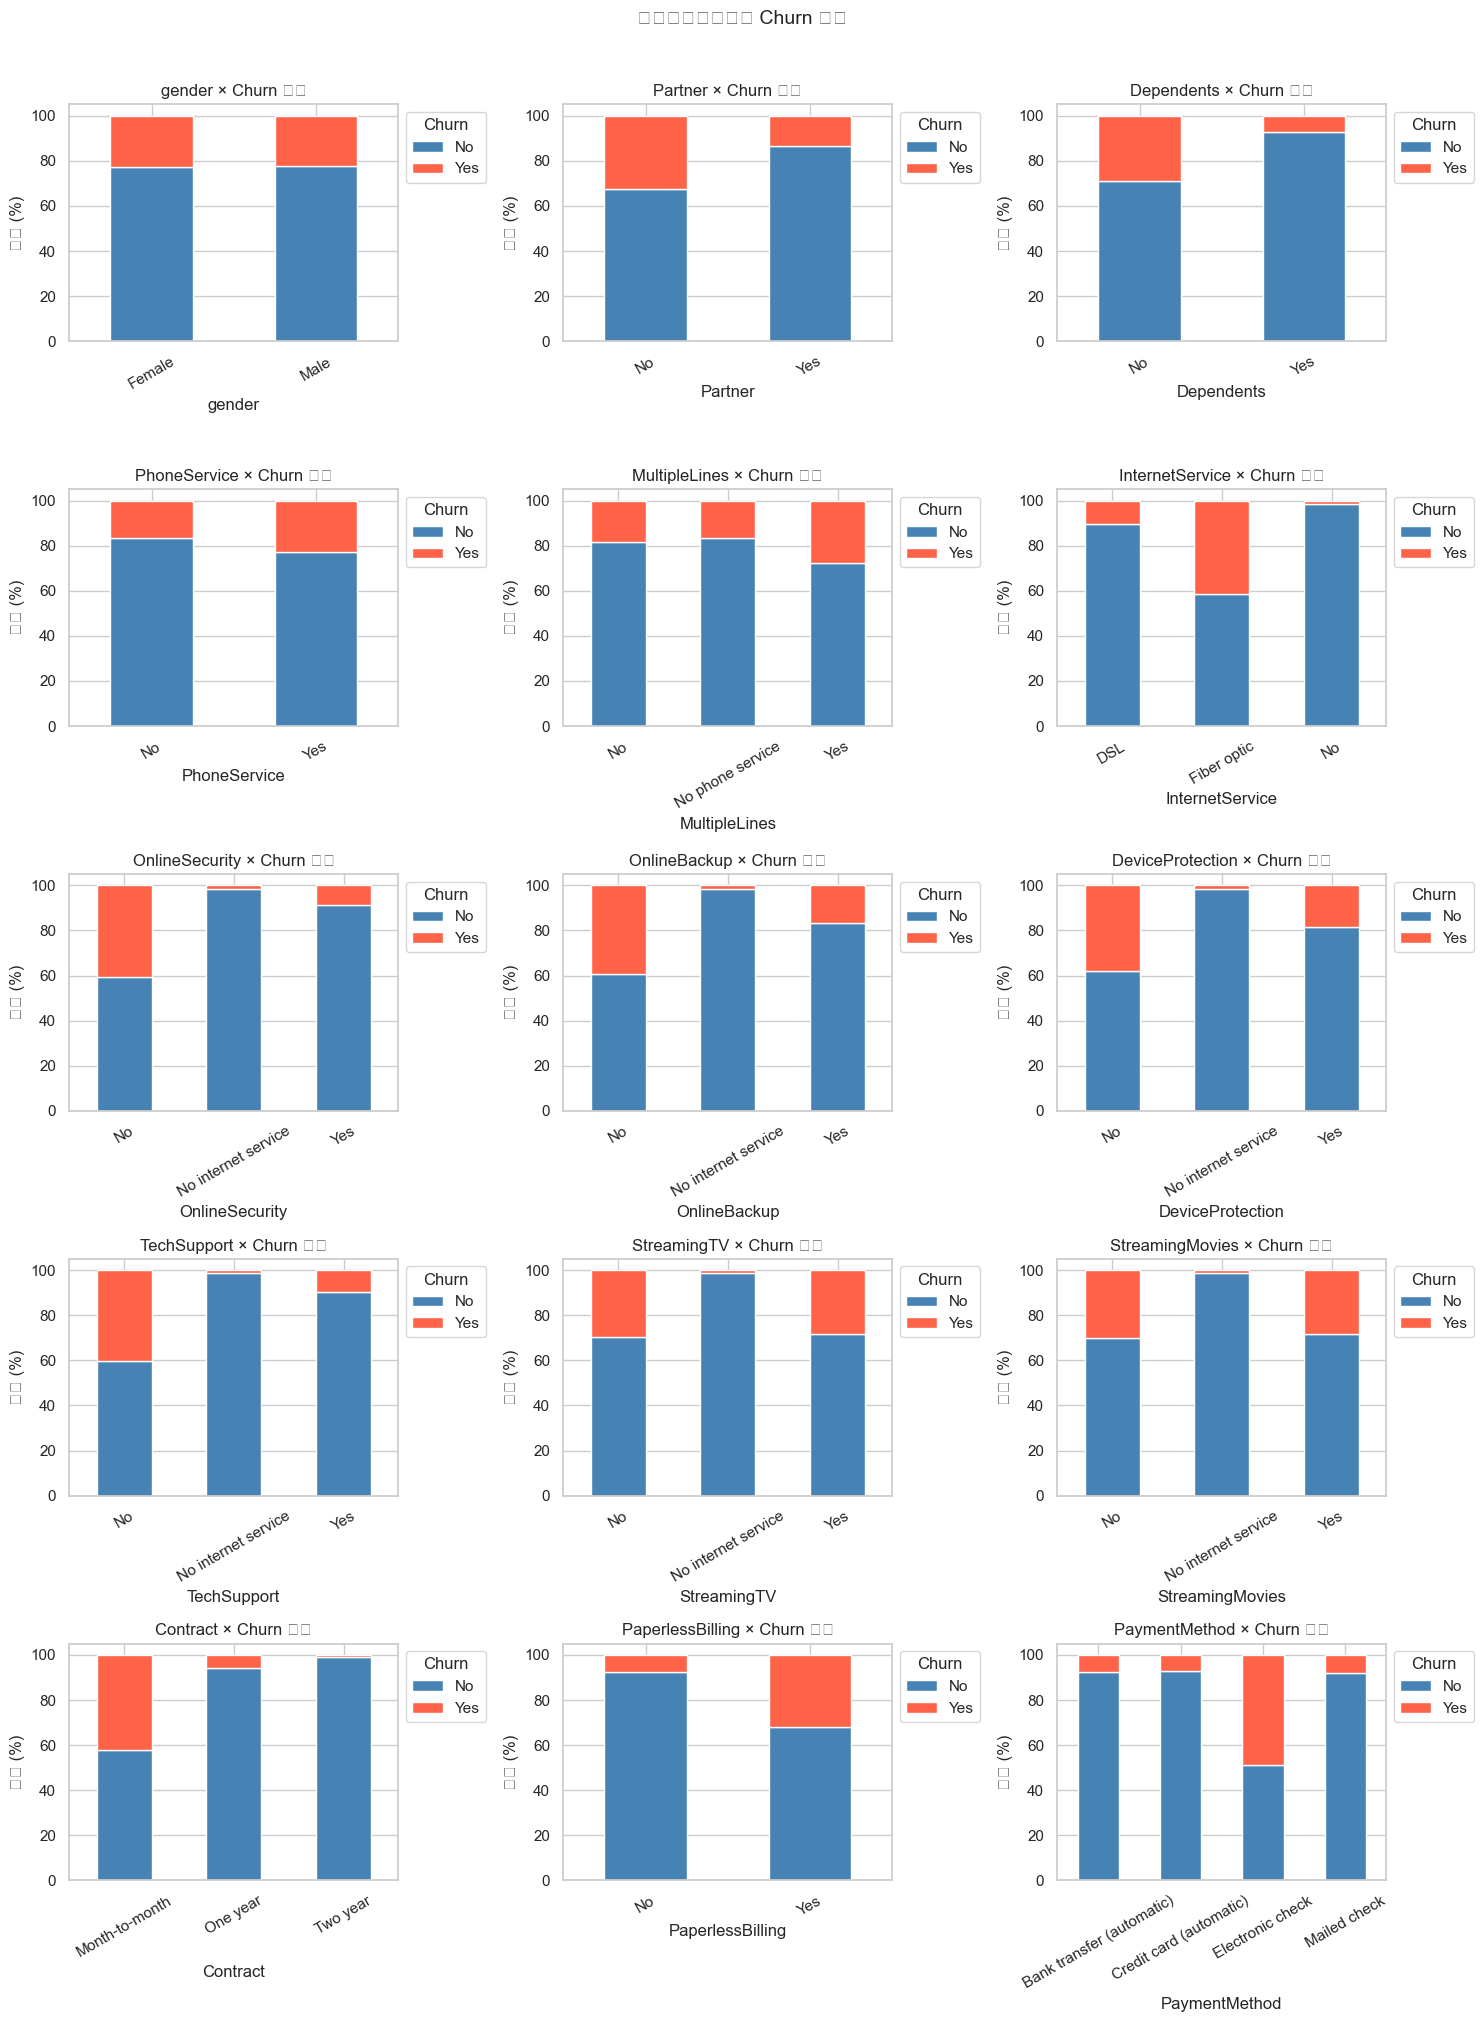

In [36]:
# カテゴリ列ごとの Churn 割合 棒グラフ
n = len(cat_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = train.groupby(col)["Churn"].value_counts(normalize=True).unstack().fillna(0) * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color={"No": "steelblue", "Yes": "tomato"}, rot=30)
    axes[i].set_title(f"{col} × Churn 割合")
    axes[i].set_ylabel("割合 (%)")
    axes[i].legend(title="Churn", bbox_to_anchor=(1, 1))

# 余ったサブプロットを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("カテゴリ列ごとの Churn 割合", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

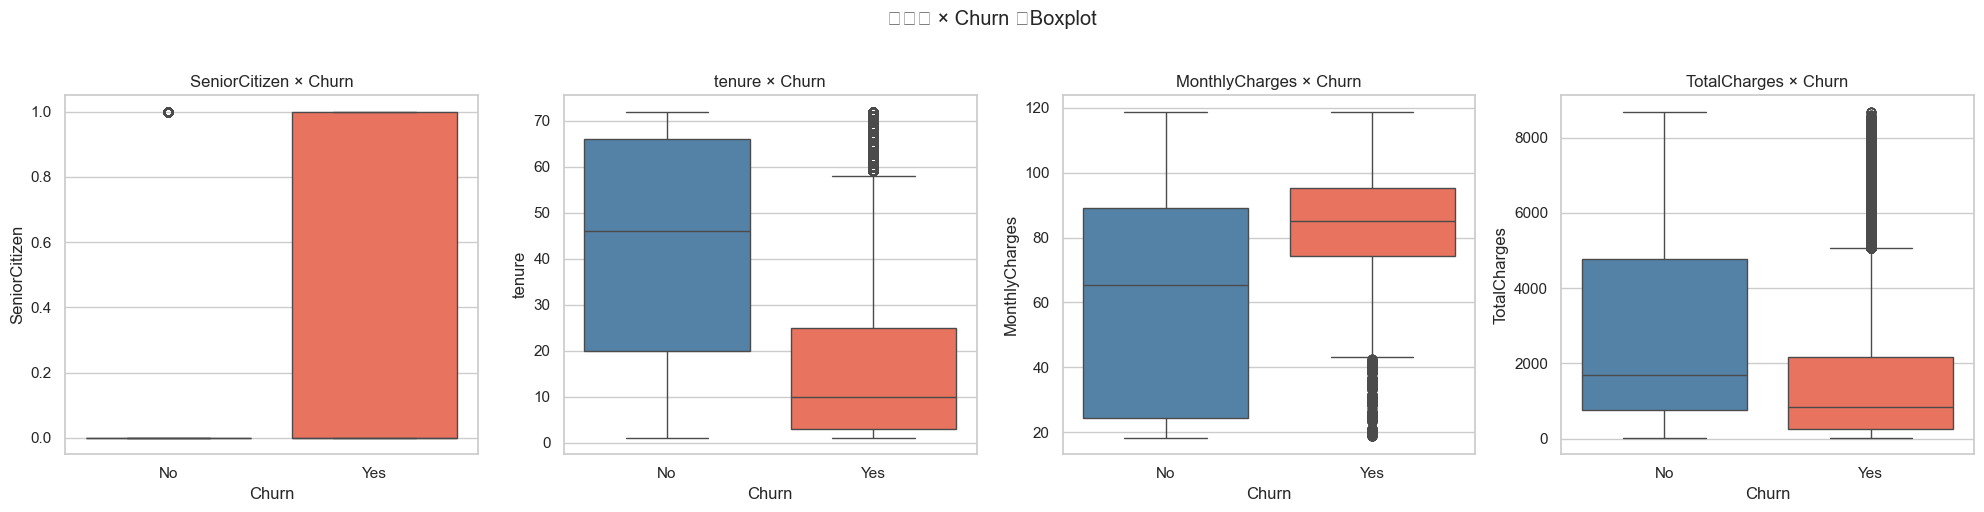

In [37]:
# 数値列 × Churn の Box plot
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=train, x="Churn", y=col, ax=ax,
                palette={"No": "steelblue", "Yes": "tomato"})
    ax.set_title(f"{col} × Churn")
plt.suptitle("数値列 × Churn のBoxplot", y=1.02)
plt.tight_layout()
plt.show()

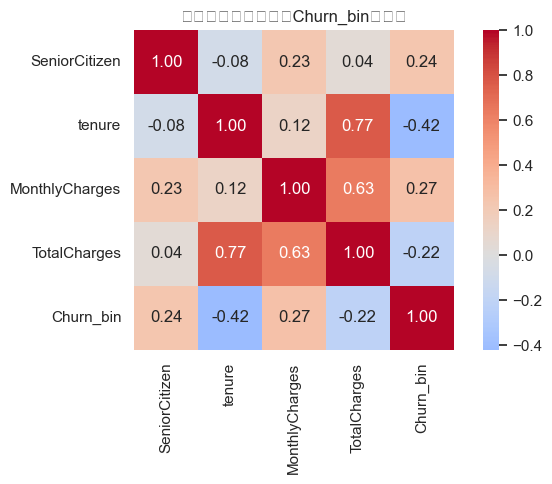

In [38]:
# 数値列の相関ヒートマップ
corr_df = train[num_cols + ["Churn"]].copy()
corr_df["Churn_bin"] = (corr_df["Churn"] == "Yes").astype(int)
corr_df = corr_df.drop(columns=["Churn"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, ax=ax)
ax.set_title("数値列の相関行列（Churn_bin含む）")
plt.tight_layout()
plt.show()

## 12. 前処理に向けた確認ポイントの整理

In [39]:
# 前処理に向けた確認ポイントをまとめて表示
print("=" * 60)
print("【前処理チェックリスト】")
print("=" * 60)

# 1. 除外候補（ID列）
print("\n[1] 除外推奨列（ID等）")
print("  - id : 行識別子のみ → モデルから除外")

# 2. 欠損補完候補
re_missing = train.isnull().sum()
re_missing = re_missing[re_missing > 0]
if re_missing.empty:
    print("\n[2] 欠損補完候補: なし（欠損値なし）")
else:
    print(f"\n[2] 欠損補完候補:")
    for col, cnt in re_missing.items():
        pct = cnt / len(train) * 100
        dtype = "数値" if train[col].dtype != object else "カテゴリ"
        print(f"  - {col} : {cnt}件 ({pct:.1f}%)  [{dtype}]")

# 3. エンコーディング対象
print(f"\n[3] ラベル/One-Hot エンコーディング対象 ({len(cat_cols)}列)")
for col in cat_cols:
    n_unique = train[col].nunique()
    print(f"  - {col} : ユニーク数 {n_unique}")

# 4. スケーリング候補
print(f"\n[4] スケーリング候補（数値列）")
for col in num_cols:
    mn, mx = train[col].min(), train[col].max()
    print(f"  - {col} : min={mn:.2f}, max={mx:.2f}")

# 5. 目的変数の変換
print("\n[5] 目的変数の変換")
print("  - Churn (Yes/No) → 1/0 に変換して学習に使用")

print("\n" + "=" * 60)

【前処理チェックリスト】

[1] 除外推奨列（ID等）
  - id : 行識別子のみ → モデルから除外

[2] 欠損補完候補: なし（欠損値なし）

[3] ラベル/One-Hot エンコーディング対象 (15列)
  - gender : ユニーク数 2
  - Partner : ユニーク数 2
  - Dependents : ユニーク数 2
  - PhoneService : ユニーク数 2
  - MultipleLines : ユニーク数 3
  - InternetService : ユニーク数 3
  - OnlineSecurity : ユニーク数 3
  - OnlineBackup : ユニーク数 3
  - DeviceProtection : ユニーク数 3
  - TechSupport : ユニーク数 3
  - StreamingTV : ユニーク数 3
  - StreamingMovies : ユニーク数 3
  - Contract : ユニーク数 3
  - PaperlessBilling : ユニーク数 2
  - PaymentMethod : ユニーク数 4

[4] スケーリング候補（数値列）
  - SeniorCitizen : min=0.00, max=1.00
  - tenure : min=1.00, max=72.00
  - MonthlyCharges : min=18.25, max=118.75
  - TotalCharges : min=18.80, max=8684.80

[5] 目的変数の変換
  - Churn (Yes/No) → 1/0 に変換して学習に使用

